In [2]:
# ============================================================
# 1. LOAD PROCESSED DATA
# ============================================================

import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


In [3]:
# ============================================================
# 2. FEATURE SCALING
# ============================================================
#
# Logistic Regression is sensitive to feature scale.
# StandardScaler transforms features to mean=0, std=1.
#
# fit_transform on train: learns scale parameters from train.
# transform on test: applies same scale — never fit on test
# to avoid data leakage.
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [4]:
# ============================================================
# 3. LOGISTIC REGRESSION — BASELINE MODEL
# ============================================================
#
# Logistic Regression is the starting point for binary
# classification. It is interpretable, fast, and provides
# a solid baseline to compare against more complex models.
#
# max_iter=1000: default 100 iterations is often insufficient
# for convergence on this dataset.
# random_state=42: reproducibility.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score,
    classification_report
)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("===== LOGISTIC REGRESSION =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr))

===== LOGISTIC REGRESSION =====
Accuracy:  0.8038
Precision: 0.6476
Recall:    0.5749
F1:        0.6091
ROC-AUC:   0.8357

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [5]:
# ============================================================
# 4. CROSS VALIDATION
# ============================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation ROC-AUC Scores:")
print(cv_scores)

print(f"\nMean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Std ROC-AUC:  {cv_scores.std():.4f}")

Cross Validation ROC-AUC Scores:
[0.83663665 0.87407986 0.8408375  0.81921174 0.85914712]

Mean ROC-AUC: 0.8460
Std ROC-AUC:  0.0189


In [6]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

Accuracy:  0.8038
Precision: 0.6476
Recall:    0.5749
F1:        0.6091
ROC-AUC:   0.8357


In [7]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Logistic Regression — Results

Logistic Regression achieved a ROC-AUC of 0.8357 on the test set and a mean cross-validation ROC-AUC of 0.8460 (±0.0189), indicating good predictive performance and stable generalization across folds.

The model reached 80.4% accuracy, with a precision of 64.8% and a recall of 57.5% for churned customers. While the model correctly identifies a substantial portion of customers at risk of churn, nearly 42% of churn cases remain undetected, suggesting room for improvement.

Overall, Logistic Regression provides a strong and interpretable baseline for comparison against more complex models such as Random Forest.

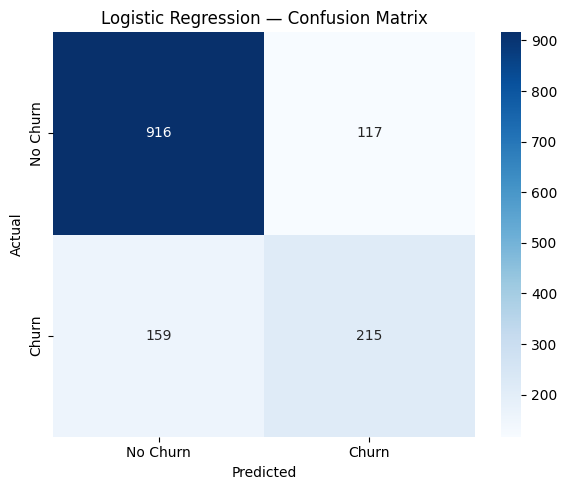

In [8]:
# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 6. RANDOM FOREST
# ============================================================
#
# Random Forest is an ensemble of decision trees.
# It handles non-linear relationships and is less sensitive
# to feature scale — no scaling required.
#
# n_estimators=100: number of trees in the forest.
# random_state=42: reproducibility.
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("===== RANDOM FOREST =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf))

===== RANDOM FOREST =====
Accuracy:  0.7896
Precision: 0.6258
Recall:    0.5187
F1:        0.5673
ROC-AUC:   0.8165

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [10]:
# ============================================================
# 7. RANDOM FOREST — CROSS VALIDATION
# ============================================================

from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation ROC-AUC Scores:")
print(cv_scores_rf)

print(f"\nMean ROC-AUC: {cv_scores_rf.mean():.4f}")
print(f"Std ROC-AUC:  {cv_scores_rf.std():.4f}")

Cross Validation ROC-AUC Scores:
[0.82267162 0.83669941 0.8242892  0.80288411 0.82993149]

Mean ROC-AUC: 0.8233
Std ROC-AUC:  0.0113


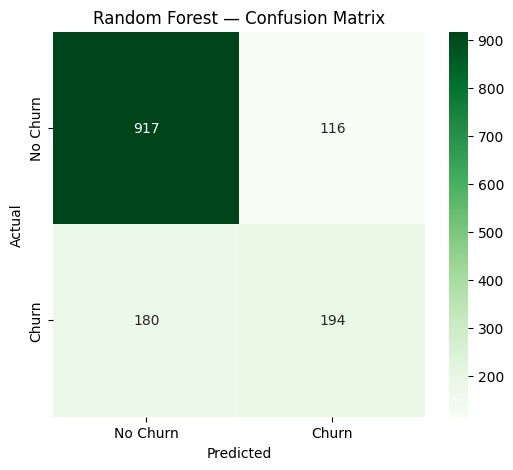

In [11]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Comparison

Two classification algorithms were evaluated for customer churn prediction:

- Logistic Regression (baseline model)
- Random Forest Classifier

### Performance Summary

| Metric | Logistic Regression | Random Forest |
|----------|----------:|----------:|
| Accuracy | 0.8038 | 0.7896 |
| Precision | 0.6476 | 0.6258 |
| Recall | 0.5749 | 0.5187 |
| F1 Score | 0.6091 | 0.5673 |
| ROC-AUC | 0.8357 | 0.8165 |
| CV ROC-AUC | 0.8460 | 0.8233 |

### Key Findings

- Logistic Regression outperformed Random Forest across all evaluation metrics.
- The largest improvement was observed in recall (57.5% vs 51.9%), meaning Logistic Regression identified a higher proportion of customers who actually churned.
- Cross-validation results also favored Logistic Regression, indicating better generalization performance.
- Despite being a more complex algorithm, Random Forest did not provide additional predictive value on this dataset.

### Model Selection

This result is a common finding in practice. When the underlying relationships between features and the target variable are relatively linear, simpler models often match or outperform more complex ones. Logistic Regression is also preferred here for its interpretability, as model coefficients can be directly linked to business insights.

In [12]:
# ============================================================
# 8. LOGISTIC REGRESSION — class_weight='balanced'
# ============================================================
#
# class_weight='balanced' adjusts weights inversely proportional
# to class frequency. This penalizes misclassification of the
# minority class (churn) more heavily, improving recall at the
# cost of some precision.
# ============================================================

lr_balanced = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight="balanced"
)
lr_balanced.fit(X_train_scaled, y_train)

y_pred_lr_bal = lr_balanced.predict(X_test_scaled)
y_prob_lr_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]

print("===== LOGISTIC REGRESSION (balanced) =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr_bal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_bal):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr_bal):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_lr_bal):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr_bal):.4f}")
print()
print(classification_report(y_test, y_pred_lr_bal))

===== LOGISTIC REGRESSION (balanced) =====
Accuracy:  0.7264
Precision: 0.4909
Recall:    0.7968
F1:        0.6075
ROC-AUC:   0.8350

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [13]:
# ============================================================
# 6. RANDOM FOREST — BALANCED MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Instantiate the model with balanced class weights
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# Note: Training on NON-scaled data
rf_balanced.fit(X_train, y_train)

# Predictions
y_pred_rf_bal = rf_balanced.predict(X_test)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

# Results
print("===== RANDOM FOREST (BALANCED) =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_bal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_bal):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_bal):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_rf_bal):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf_bal):.4f}")
print()
print(classification_report(y_test, y_pred_rf_bal))

===== RANDOM FOREST (BALANCED) =====
Accuracy:  0.7889
Precision: 0.6323
Recall:    0.4920
F1:        0.5534
ROC-AUC:   0.8177

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [17]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.347613,1.347613
2,MonthlyCharges,-0.851551,0.851551
10,InternetService_Fiber optic,0.727745,0.727745
3,TotalCharges,0.639028,0.639028
25,Contract_Two year,-0.602591,0.602591
24,Contract_One year,-0.310898,0.310898
21,StreamingTV_Yes,0.249702,0.249702
23,StreamingMovies_Yes,0.236368,0.236368
9,MultipleLines_Yes,0.214359,0.214359
28,PaymentMethod_Electronic check,0.181473,0.181473


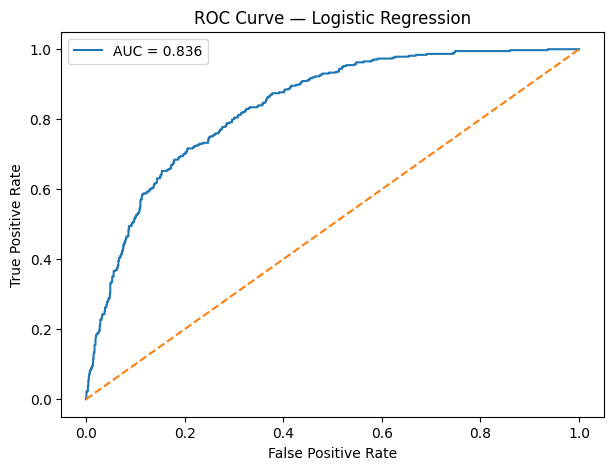

In [16]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_lr):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()